**IMPORTING DATASET**

In [2]:
!pip install -q kaggle

from google.colab import files

uploaded = files.upload()

Saving kaggle.json to kaggle.json


In [3]:
import os

os.makedirs("/root/.kaggle", exist_ok=True)

!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json


In [4]:
!kaggle datasets download -d youssefsalahzakria/fruit-and-vegetables-classification

Dataset URL: https://www.kaggle.com/datasets/youssefsalahzakria/fruit-and-vegetables-classification
License(s): CC0-1.0
100% 4.82G/4.82G [00:58<00:00, 87.8MB/s]



In [5]:
import zipfile
import os

zip_path = "/content/fruit-and-vegetables-classification.zip"
extract_path = "/content/fruit_vegetables"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted to:", extract_path)

Dataset extracted to: /content/fruit_vegetables


In [7]:
!find /content/fruit_vegetables -type f | head -20

/content/fruit_vegetables/validation/Okra/image_88.jpg
/content/fruit_vegetables/validation/Okra/image_34.jpg
/content/fruit_vegetables/validation/Okra/image_76.jpg
/content/fruit_vegetables/validation/Okra/image_80.jpg
/content/fruit_vegetables/validation/Okra/image_31.jpg
/content/fruit_vegetables/validation/Okra/image_13.jpg
/content/fruit_vegetables/validation/Okra/image_16.jpg
/content/fruit_vegetables/validation/Okra/image_49.jpg
/content/fruit_vegetables/validation/Okra/image_27.jpg
/content/fruit_vegetables/validation/Okra/image_64.jpg
/content/fruit_vegetables/validation/Okra/image_3.jpg
/content/fruit_vegetables/validation/Okra/image_70.jpg
/content/fruit_vegetables/validation/Okra/image_63.jpg
/content/fruit_vegetables/validation/Okra/image_9.jpg
/content/fruit_vegetables/validation/Okra/image_54.jpg
/content/fruit_vegetables/validation/Okra/image_57.jpg
/content/fruit_vegetables/validation/Okra/image_72.jpg
/content/fruit_vegetables/validation/Okra/image_78.jpg
/content/fru

In [8]:
import os

print(os.listdir("/content"))

['.config', 'kaggle.json', 'fruit-and-vegetables-classification.zip', 'fruit_vegetables', 'sample_data']


In [9]:
!find /content/fruit_vegetables -maxdepth 3 -type d | head -100

/content/fruit_vegetables
/content/fruit_vegetables/validation
/content/fruit_vegetables/validation/Okra
/content/fruit_vegetables/validation/Strawberry
/content/fruit_vegetables/validation/Lettuce
/content/fruit_vegetables/validation/Peas
/content/fruit_vegetables/validation/Dragonfruit
/content/fruit_vegetables/validation/Turnip
/content/fruit_vegetables/validation/Jalepeno
/content/fruit_vegetables/validation/Orange
/content/fruit_vegetables/validation/Spinach
/content/fruit_vegetables/validation/Kiwi
/content/fruit_vegetables/validation/Pumpkin
/content/fruit_vegetables/validation/Dates
/content/fruit_vegetables/validation/Corn
/content/fruit_vegetables/validation/Onion
/content/fruit_vegetables/validation/Raddish
/content/fruit_vegetables/validation/Paprika
/content/fruit_vegetables/validation/Cauliflower
/content/fruit_vegetables/validation/Tomato
/content/fruit_vegetables/validation/Carrot
/content/fruit_vegetables/validation/Cucumber
/content/fruit_vegetables/validation/Waterme

**TRAIN,VALIDATION,TEST CLASSES**

In [10]:
import os

base_path = "/content/fruit_vegetables"

for split in ["train", "validation", "test"]:
    split_path = os.path.join(base_path, split)
    classes = sorted(os.listdir(split_path))

    print(f"{split}: {len(classes)} classes")
    print(classes)
    print()

train: 50 classes
['Apple', 'Avocado', 'Banana', 'Beetroot', 'Blackberry', 'Blueberry', 'Broccoli', 'Cabbage', 'Capsicum', 'Carrot', 'Cauliflower', 'Chilli Peper', 'Corn', 'Cucumber', 'Dates', 'Dragonfruit', 'Eggplant', 'Fig', 'Garlic', 'Ginger', 'Grapes', 'Guava', 'Jalepeno', 'Kiwi', 'Lemon', 'Lettuce', 'Mango', 'Mushroom', 'Okra', 'Olive', 'Onion', 'Orange', 'Paprika', 'Peanuts', 'Pear', 'Peas', 'Pineapple', 'Pomegranate', 'Potato', 'Pumpkin', 'Raddish', 'Rambutan', 'Soy Beans', 'Spinach', 'Strawberry', 'Sweetcorn', 'Sweetpotato', 'Tomato', 'Turnip', 'Watermelon']

validation: 50 classes
['Apple', 'Avocado', 'Banana', 'Beetroot', 'Blackberry', 'Blueberry', 'Broccoli', 'Cabbage', 'Capsicum', 'Carrot', 'Cauliflower', 'Chilli peper', 'Corn', 'Cucumber', 'Dates', 'Dragonfruit', 'Eggplant', 'Fig', 'Garlic', 'Ginger', 'Grapes', 'Guava', 'Jalepeno', 'Kiwi', 'Lemon', 'Lettuce', 'Mango', 'Mushroom', 'Okra', 'Olive', 'Onion', 'Orange', 'Paprika', 'Peanuts', 'Pear', 'Peas', 'Pineapple', 'Pomegr

**COUNT OF EACH ITEM**

In [11]:
import os

base_path = "/content/fruit_vegetables"

for split in ["train", "validation", "test"]:
    split_path = os.path.join(base_path, split)

    total_images = 0

    print(f"\n{split.upper()}")

    for class_name in sorted(os.listdir(split_path)):
        class_path = os.path.join(split_path, class_name)

        if os.path.isdir(class_path):
            count = len([
                f for f in os.listdir(class_path)
                if os.path.isfile(os.path.join(class_path, f))
            ])

            total_images += count
            print(f"{class_name:20s}: {count}")

    print(f"Total images: {total_images}")


TRAIN
Apple               : 1321
Avocado             : 1041
Banana              : 1866
Beetroot            : 224
Blackberry          : 891
Blueberry           : 669
Broccoli            : 1473
Cabbage             : 192
Capsicum            : 960
Carrot              : 836
Cauliflower         : 1229
Chilli Peper        : 400
Corn                : 1284
Cucumber            : 1442
Dates               : 422
Dragonfruit         : 951
Eggplant            : 835
Fig                 : 802
Garlic              : 498
Ginger              : 753
Grapes              : 1740
Guava               : 667
Jalepeno            : 133
Kiwi                : 1152
Lemon               : 1284
Lettuce             : 291
Mango               : 1380
Mushroom            : 353
Okra                : 416
Olive               : 598
Onion               : 1216
Orange              : 2697
Paprika             : 83
Peanuts             : 441
Pear                : 1114
Peas                : 1470
Pineapple           : 1668
Pomegranate     

In [13]:
from PIL import Image
import os

train_path = "/content/fruit_vegetables/train"

# Pick the first class
class_name = sorted(os.listdir(train_path))[0]

class_path = os.path.join(train_path, class_name)

# Pick the first image
image_name = os.listdir(class_path)[0]
image_path = os.path.join(class_path, image_name)

image = Image.open(image_path)

print("Class:", class_name)
print("Image:", image_name)
print("Image size:", image.size)
print("Image mode:", image.mode)

Class: Apple
Image: image_943.jpg
Image size: (256, 256)
Image mode: RGB


In [14]:
import os
import torch
from collections import Counter

# Dataset path
DATA_DIR = "/content/fruit_vegetables"

# Training directory
TRAIN_DIR = os.path.join(DATA_DIR, "train")

print("Dataset path:", DATA_DIR)
print("Training path:", TRAIN_DIR)

Dataset path: /content/fruit_vegetables
Training path: /content/fruit_vegetables/train


In [15]:
classes = sorted([
    class_name
    for class_name in os.listdir(TRAIN_DIR)
    if os.path.isdir(os.path.join(TRAIN_DIR, class_name))
])

class_to_idx = {
    class_name: idx
    for idx, class_name in enumerate(classes)
}

idx_to_class = {
    idx: class_name
    for class_name, idx in class_to_idx.items()
}

print("Number of classes:", len(classes))
print("\nClass mapping:")
for class_name, idx in class_to_idx.items():
    print(f"{idx:2d} → {class_name}")

Number of classes: 50

Class mapping:
 0 → Apple
 1 → Avocado
 2 → Banana
 3 → Beetroot
 4 → Blackberry
 5 → Blueberry
 6 → Broccoli
 7 → Cabbage
 8 → Capsicum
 9 → Carrot
10 → Cauliflower
11 → Chilli Peper
12 → Corn
13 → Cucumber
14 → Dates
15 → Dragonfruit
16 → Eggplant
17 → Fig
18 → Garlic
19 → Ginger
20 → Grapes
21 → Guava
22 → Jalepeno
23 → Kiwi
24 → Lemon
25 → Lettuce
26 → Mango
27 → Mushroom
28 → Okra
29 → Olive
30 → Onion
31 → Orange
32 → Paprika
33 → Peanuts
34 → Pear
35 → Peas
36 → Pineapple
37 → Pomegranate
38 → Potato
39 → Pumpkin
40 → Raddish
41 → Rambutan
42 → Soy Beans
43 → Spinach
44 → Strawberry
45 → Sweetcorn
46 → Sweetpotato
47 → Tomato
48 → Turnip
49 → Watermelon


In [16]:
class_counts = {}

for class_name in classes:
    class_path = os.path.join(TRAIN_DIR, class_name)

    image_count = len([
        file
        for file in os.listdir(class_path)
        if os.path.isfile(os.path.join(class_path, file))
    ])

    class_counts[class_name] = image_count

print("Class counts:\n")

for class_name, count in class_counts.items():
    print(f"{class_name:20s} → {count}")

Class counts:

Apple                → 1321
Avocado              → 1041
Banana               → 1866
Beetroot             → 224
Blackberry           → 891
Blueberry            → 669
Broccoli             → 1473
Cabbage              → 192
Capsicum             → 960
Carrot               → 836
Cauliflower          → 1229
Chilli Peper         → 400
Corn                 → 1284
Cucumber             → 1442
Dates                → 422
Dragonfruit          → 951
Eggplant             → 835
Fig                  → 802
Garlic               → 498
Ginger               → 753
Grapes               → 1740
Guava                → 667
Jalepeno             → 133
Kiwi                 → 1152
Lemon                → 1284
Lettuce              → 291
Mango                → 1380
Mushroom             → 353
Okra                 → 416
Olive                → 598
Onion                → 1216
Orange               → 2697
Paprika              → 83
Peanuts              → 441
Pear                 → 1114
Peas                 → 1470

**Calculating the class weights**

In [17]:
total_samples = sum(class_counts.values())
num_classes = len(classes)

class_weights = []

for class_name in classes:
    weight = total_samples / (num_classes * class_counts[class_name])
    class_weights.append(weight)

class_weights = torch.tensor(class_weights, dtype=torch.float32)

print("Class weights:\n")

for class_name, weight in zip(classes, class_weights):
    print(f"{class_name:20s} → {weight:.4f}")

Class weights:

Apple                → 0.6993
Avocado              → 0.8874
Banana               → 0.4951
Beetroot             → 4.1242
Blackberry           → 1.0368
Blueberry            → 1.3809
Broccoli             → 0.6272
Cabbage              → 4.8116
Capsicum             → 0.9623
Carrot               → 1.1050
Cauliflower          → 0.7517
Chilli Peper         → 2.3096
Corn                 → 0.7195
Cucumber             → 0.6407
Dates                → 2.1891
Dragonfruit          → 0.9714
Eggplant             → 1.1064
Fig                  → 1.1519
Garlic               → 1.8551
Ginger               → 1.2269
Grapes               → 0.5309
Guava                → 1.3850
Jalepeno             → 6.9460
Kiwi                 → 0.8019
Lemon                → 0.7195
Lettuce              → 3.1746
Mango                → 0.6694
Mushroom             → 2.6171
Okra                 → 2.2207
Olive                → 1.5448
Onion                → 0.7597
Orange               → 0.3425
Paprika              → 1

**Creating transforms**

In [18]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

**Dataset Creation**

In [19]:
from torchvision.datasets import ImageFolder

train_dataset = ImageFolder(
    root=os.path.join(DATA_DIR, "train"),
    transform=train_transform
)

val_dataset = ImageFolder(
    root=os.path.join(DATA_DIR, "validation"),
    transform=val_test_transform
)

test_dataset = ImageFolder(
    root=os.path.join(DATA_DIR, "test"),
    transform=val_test_transform
)

In [20]:
print("Number of classes:", len(train_dataset.classes))

print("\nClass mapping:")
print(train_dataset.class_to_idx)

Number of classes: 50

Class mapping:
{'Apple': 0, 'Avocado': 1, 'Banana': 2, 'Beetroot': 3, 'Blackberry': 4, 'Blueberry': 5, 'Broccoli': 6, 'Cabbage': 7, 'Capsicum': 8, 'Carrot': 9, 'Cauliflower': 10, 'Chilli Peper': 11, 'Corn': 12, 'Cucumber': 13, 'Dates': 14, 'Dragonfruit': 15, 'Eggplant': 16, 'Fig': 17, 'Garlic': 18, 'Ginger': 19, 'Grapes': 20, 'Guava': 21, 'Jalepeno': 22, 'Kiwi': 23, 'Lemon': 24, 'Lettuce': 25, 'Mango': 26, 'Mushroom': 27, 'Okra': 28, 'Olive': 29, 'Onion': 30, 'Orange': 31, 'Paprika': 32, 'Peanuts': 33, 'Pear': 34, 'Peas': 35, 'Pineapple': 36, 'Pomegranate': 37, 'Potato': 38, 'Pumpkin': 39, 'Raddish': 40, 'Rambutan': 41, 'Soy Beans': 42, 'Spinach': 43, 'Strawberry': 44, 'Sweetcorn': 45, 'Sweetpotato': 46, 'Tomato': 47, 'Turnip': 48, 'Watermelon': 49}


In [21]:
print("Train classes:", train_dataset.classes)
print("Validation classes:", val_dataset.classes)
print("Test classes:", test_dataset.classes)

Train classes: ['Apple', 'Avocado', 'Banana', 'Beetroot', 'Blackberry', 'Blueberry', 'Broccoli', 'Cabbage', 'Capsicum', 'Carrot', 'Cauliflower', 'Chilli Peper', 'Corn', 'Cucumber', 'Dates', 'Dragonfruit', 'Eggplant', 'Fig', 'Garlic', 'Ginger', 'Grapes', 'Guava', 'Jalepeno', 'Kiwi', 'Lemon', 'Lettuce', 'Mango', 'Mushroom', 'Okra', 'Olive', 'Onion', 'Orange', 'Paprika', 'Peanuts', 'Pear', 'Peas', 'Pineapple', 'Pomegranate', 'Potato', 'Pumpkin', 'Raddish', 'Rambutan', 'Soy Beans', 'Spinach', 'Strawberry', 'Sweetcorn', 'Sweetpotato', 'Tomato', 'Turnip', 'Watermelon']
Validation classes: ['Apple', 'Avocado', 'Banana', 'Beetroot', 'Blackberry', 'Blueberry', 'Broccoli', 'Cabbage', 'Capsicum', 'Carrot', 'Cauliflower', 'Chilli peper', 'Corn', 'Cucumber', 'Dates', 'Dragonfruit', 'Eggplant', 'Fig', 'Garlic', 'Ginger', 'Grapes', 'Guava', 'Jalepeno', 'Kiwi', 'Lemon', 'Lettuce', 'Mango', 'Mushroom', 'Okra', 'Olive', 'Onion', 'Orange', 'Paprika', 'Peanuts', 'Pear', 'Peas', 'Pineapple', 'Pomegranate',

In [22]:
print("\nTrain mapping:")
print(train_dataset.class_to_idx)

print("\nValidation mapping:")
print(val_dataset.class_to_idx)

print("\nTest mapping:")
print(test_dataset.class_to_idx)


Train mapping:
{'Apple': 0, 'Avocado': 1, 'Banana': 2, 'Beetroot': 3, 'Blackberry': 4, 'Blueberry': 5, 'Broccoli': 6, 'Cabbage': 7, 'Capsicum': 8, 'Carrot': 9, 'Cauliflower': 10, 'Chilli Peper': 11, 'Corn': 12, 'Cucumber': 13, 'Dates': 14, 'Dragonfruit': 15, 'Eggplant': 16, 'Fig': 17, 'Garlic': 18, 'Ginger': 19, 'Grapes': 20, 'Guava': 21, 'Jalepeno': 22, 'Kiwi': 23, 'Lemon': 24, 'Lettuce': 25, 'Mango': 26, 'Mushroom': 27, 'Okra': 28, 'Olive': 29, 'Onion': 30, 'Orange': 31, 'Paprika': 32, 'Peanuts': 33, 'Pear': 34, 'Peas': 35, 'Pineapple': 36, 'Pomegranate': 37, 'Potato': 38, 'Pumpkin': 39, 'Raddish': 40, 'Rambutan': 41, 'Soy Beans': 42, 'Spinach': 43, 'Strawberry': 44, 'Sweetcorn': 45, 'Sweetpotato': 46, 'Tomato': 47, 'Turnip': 48, 'Watermelon': 49}

Validation mapping:
{'Apple': 0, 'Avocado': 1, 'Banana': 2, 'Beetroot': 3, 'Blackberry': 4, 'Blueberry': 5, 'Broccoli': 6, 'Cabbage': 7, 'Capsicum': 8, 'Carrot': 9, 'Cauliflower': 10, 'Chilli peper': 11, 'Corn': 12, 'Cucumber': 13, 'Dates

**Creating DataLoader**

In [23]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [24]:
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Labels:", labels[:10])

Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])
Labels: tensor([37, 17, 20, 23,  8,  6, 34, 11, 42, 38])


**TRANSFER LEARNING**

In [25]:
import torch
import torch.nn as nn
from torchvision import models

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

googlenet = models.googlenet(weights="DEFAULT")

print(googlenet)

Device: cuda
Downloading: "https://download.pytorch.org/models/googlenet-1378be20.pth" to /root/.cache/torch/hub/checkpoints/googlenet-1378be20.pth


100%|██████████| 49.7M/49.7M [00:00<00:00, 163MB/s]

GoogLeNet(
  (conv1): BasicConv2d(
    (conv): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (conv2): BasicConv2d(
    (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (conv3): BasicConv2d(
    (conv): Conv2d(64, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(192, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (inception3a): Inception(
    (branch1): BasicConv2d(
      (conv): Conv2d(192, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track

In [26]:
print("Original classifier:")
print(googlenet.fc)

print("\nInput features:", googlenet.fc.in_features)
print("Original output classes:", googlenet.fc.out_features)
print("Our output classes:", num_classes)

Original classifier:
Linear(in_features=1024, out_features=1000, bias=True)

Input features: 1024
Original output classes: 1000
Our output classes: 50


In [27]:
# Number of classes in our dataset
num_classes = len(train_dataset.classes)

# Replace the original ImageNet classifier
googlenet.fc = nn.Linear(
    googlenet.fc.in_features,
    num_classes
)

print(googlenet.fc)

Linear(in_features=1024, out_features=50, bias=True)


In [28]:
for param in googlenet.parameters():
    param.requires_grad = True

In [29]:
googlenet = googlenet.to(device)

print("Model device:", next(googlenet.parameters()).device)

Model device: cuda:0


**Loss Function and Adam Optimizer**

In [30]:
criterion = nn.CrossEntropyLoss(
    weight=class_weights.to(device)
)

optimizer = torch.optim.Adam(
    googlenet.parameters(),
    lr=1e-4
)

print("Loss function:", criterion)
print("Optimizer:", optimizer)

Loss function: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0
)


**TRAINING LOOP**

In [31]:
EPOCHS = 15

train_losses = []
train_accuracies = []

val_losses = []
val_accuracies = []

for epoch in range(EPOCHS):

    # -------------------------
    # Training
    # -------------------------
    googlenet.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        # Clear previous gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = googlenet(images)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update parameters
        optimizer.step()

        # Statistics
        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_accuracy = 100 * correct / total

    # -------------------------
    # Validation
    # -------------------------
    googlenet.eval()

    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = googlenet(images)

            loss = criterion(outputs, labels)

            val_running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = val_running_loss / len(val_loader)
    val_accuracy = 100 * val_correct / val_total

    # Store metrics
    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)

    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    print(
        f"Epoch [{epoch + 1}/{EPOCHS}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Accuracy: {train_accuracy:.2f}% "
        f"Val Loss: {val_loss:.4f} "
        f"Val Accuracy: {val_accuracy:.2f}%"
    )

/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [1/15] Train Loss: 1.2814 Train Accuracy: 69.51% Val Loss: 0.5132 Val Accuracy: 86.38%


/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [2/15] Train Loss: 0.4991 Train Accuracy: 84.90% Val Loss: 0.3772 Val Accuracy: 89.21%


/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


...

Epoch [13/15] Train Loss: 0.0871 Train Accuracy: 96.61% Val Loss: 0.2897 Val Accuracy: 92.87%


/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [14/15] Train Loss: 0.0830 Train Accuracy: 96.98% Val Loss: 0.3009 Val Accuracy: 92.62%


/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [15/15] Train Loss: 0.0775 Train Accuracy: 97.01% Val Loss: 0.3108 Val Accuracy: 92.34%


**TESTING THE MODEL**

In [32]:
googlenet.eval()

test_running_loss = 0.0
test_correct = 0
test_total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = googlenet(images)

        loss = criterion(outputs, labels)

        test_running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()

test_loss = test_running_loss / len(test_loader)
test_accuracy = 100 * test_correct / test_total

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Loss: 0.3971
Test Accuracy: 90.44%


**CLASSIFICATION REPORT**

In [33]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

googlenet.eval()

all_labels = []
all_predictions = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = googlenet(images)

        _, predictions = torch.max(outputs, 1)

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predictions.cpu().numpy())

all_labels = np.array(all_labels)
all_predictions = np.array(all_predictions)

print("Total test samples:", len(all_labels))
print("Total predictions:", len(all_predictions))

Total test samples: 13353
Total predictions: 13353


In [34]:
print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=test_dataset.classes,
        digits=4
    )
)

              precision    recall  f1-score   support

       Apple     0.9327    0.8598    0.8947       435
     Avocado     0.9443    0.9525    0.9484       463
      Banana     0.8474    0.9525    0.8969       484
    Beetroot     0.9545    0.9130    0.9333        46
  Blackberry     0.7937    1.0000    0.8850        50
   Blueberry     0.9189    0.8818    0.9000       347
    Broccoli     0.9183    0.9100    0.9142       667
     Cabbage     0.9326    0.9881    0.9595        84
    Capsicum     0.9162    0.8783    0.8969       411
      Carrot     0.8482    0.9046    0.8755       241
 Cauliflower     0.9114    0.9075    0.9095       465
Chilli Peper     0.8989    0.9412    0.9195        85
        Corn     0.7979    0.7816    0.7897       293
    Cucumber     0.9063    0.7903    0.8443       453
       Dates     0.8772    1.0000    0.9346        50
 Dragonfruit     0.9490    0.9789    0.9637       190
    Eggplant     0.9437    0.9316    0.9376       234
         Fig     0.9074    

**CONFUSION MATRIX**

In [35]:
cm = confusion_matrix(
    all_labels,
    all_predictions
)

print("Confusion matrix shape:", cm.shape)

Confusion matrix shape: (50, 50)


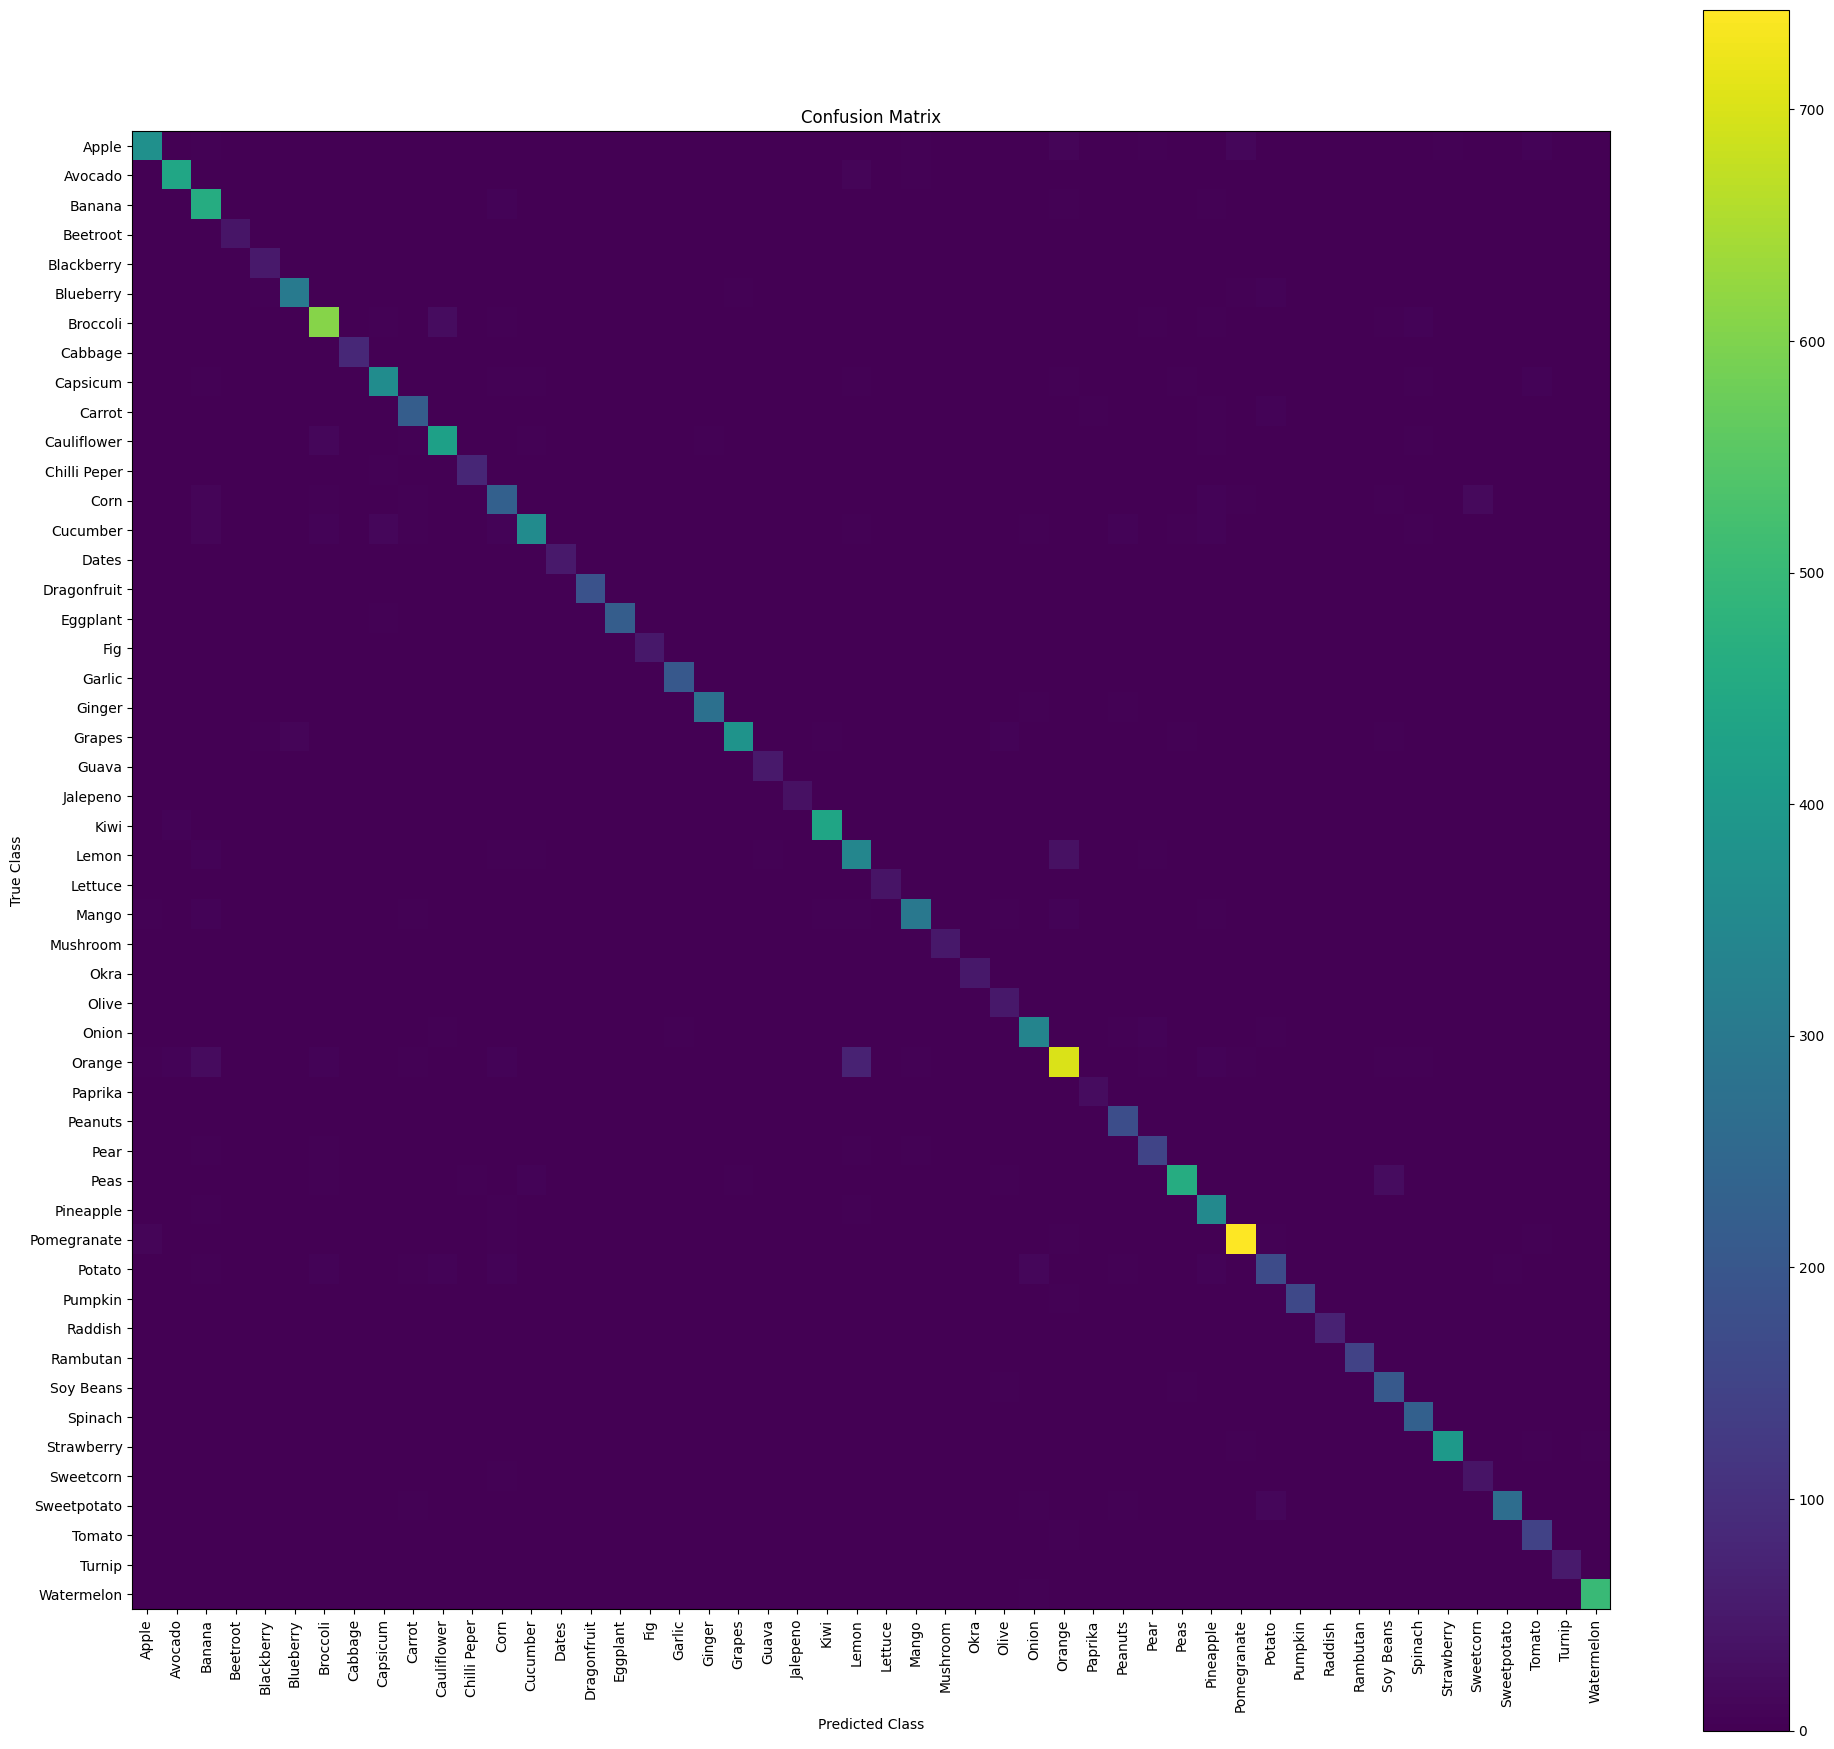

In [36]:
plt.figure(figsize=(20, 18))

plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")

plt.xticks(
    range(len(test_dataset.classes)),
    test_dataset.classes,
    rotation=90
)

plt.yticks(
    range(len(test_dataset.classes)),
    test_dataset.classes
)

plt.colorbar()

plt.tight_layout()
plt.show()

**TESTING A FRUIT IMAGE TAKEN FROM GOOGLE**

Saving Red_Apple.jpg to Red_Apple.jpg


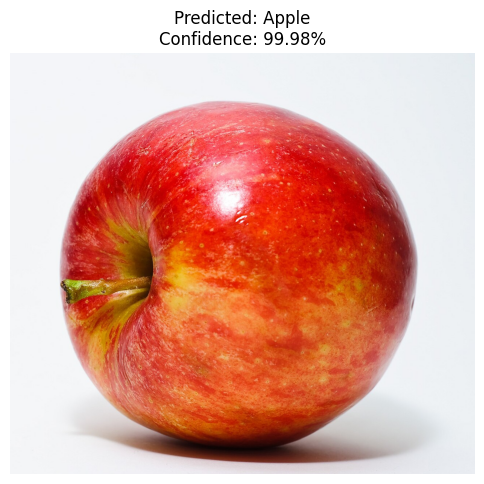

Image: Red_Apple.jpg
Predicted class: Apple
Confidence: 99.98%


In [39]:
from google.colab import files
from PIL import Image
import matplotlib.pyplot as plt
import torch

# Upload an image
uploaded = files.upload()

# Get uploaded file name
image_path = next(iter(uploaded))

# Open image
image = Image.open(image_path).convert("RGB")

# Apply validation/test preprocessing
input_tensor = val_test_transform(image)

# Add batch dimension
input_batch = input_tensor.unsqueeze(0).to(device)

# Put model in evaluation mode
googlenet.eval()

# Make prediction
with torch.no_grad():
    outputs = googlenet(input_batch)

    # Convert logits to probabilities
    probabilities = torch.softmax(outputs, dim=1)

    # Get predicted class
    predicted_index = torch.argmax(probabilities, dim=1).item()

    # Get confidence
    confidence = probabilities[0, predicted_index].item()

# Get class name
predicted_class = test_dataset.classes[predicted_index]

# Display image
plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.axis("off")
plt.title(
    f"Predicted: {predicted_class}\n"
    f"Confidence: {confidence * 100:.2f}%"
)
plt.show()

# Print result
print("Image:", image_path)
print("Predicted class:", predicted_class)
print(f"Confidence: {confidence * 100:.2f}%")